# Notebook 07: Vector Autoregression

This notebook models fuel prices, Brent crude, the exchange rate, and CPI jointly. Because CPI remains non-stationary after first differencing, the system is estimated in second differences, then forecasts are integrated back to price levels. In addition to forecast accuracy, the notebook studies stability, residual adequacy, Granger causality, impulse responses, and forecast-error variance decomposition.

# Vector autoregression (VAR)

Fit a stable VAR to the second differences of the fuel prices and macroeconomic variables. Forecast the twice-differenced system, reconstruct levels, and evaluate the fuel-price forecasts on a six-month holdout.

In [1]:
# VAR modeling, diagnostics, system analysis, and forecasting
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.api import VAR

warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("../data/dataset_final/full_data.csv")
df["date"] = pd.to_datetime(df["month"], format="%YM%m")
df = df.set_index("date").asfreq("MS")

fuel_cols = [
    "diesel_price_(GHC/litre)",
    "petrol_price_ghs/litre",
    "lpg_ghs/kg",
]
var_cols = fuel_cols + [
    "brent_price_usd_per_barrel",
    "usd/ghs_rate",
    "consumer_price_index",
]
external_cols = [
    "brent_price_usd_per_barrel",
    "usd/ghs_rate",
    "consumer_price_index",
]
horizon = 6
train = df.iloc[:-horizon]
test = df.iloc[-horizon:]

print(f"Training period: {train.index.min():%Y-%m} to {train.index.max():%Y-%m}")
print(f"Test period: {test.index.min():%Y-%m} to {test.index.max():%Y-%m}")

# CPI is not stationary after one difference, so the complete system
# is modeled in second differences for a consistent transformation.
train_diff2 = train[var_cols].diff().diff().dropna()
model = VAR(train_diff2)
lag_selection = model.select_order(maxlags=6)

Training period: 2015-07 to 2025-12
Test period: 2026-01 to 2026-06


In [4]:
# Keep only stable candidates, then choose the lowest-AIC stable model.
stable_candidates = []
for lag in range(1, 7):
    try:
        candidate_fit = model.fit(lag)
        if candidate_fit.is_stable():
            stable_candidates.append((candidate_fit.aic, lag, candidate_fit))
    except (ValueError, np.linalg.LinAlgError):
        continue

if stable_candidates:
    _, selected_lag, var_fit = min(stable_candidates, key=lambda item: item[0])
else:
    selected_lag = max(1, min(lag_selection.selected_orders.get("bic") or 1, 6))
    var_fit = model.fit(selected_lag)

print("Lag-order selection:")
print(lag_selection.summary())
print(f"Selected stable lag: {selected_lag}")
print(f"Stable VAR system: {var_fit.is_stable()}")

# Residual diagnostics for the fitted multivariate system.
print("\nVAR residual whiteness test:")
print(var_fit.test_whiteness(nlags=10))
print("\nVAR residual normality test:")
print(var_fit.test_normality())

Lag-order selection:
 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      -1.514      -1.373      0.2201      -1.457
1      -3.332      -2.346     0.03575      -2.932
2      -4.857     -3.026*    0.007813     -4.114*
3      -5.095      -2.418    0.006235      -4.008
4      -5.337      -1.815    0.005004      -3.907
5      -5.622      -1.255    0.003900      -3.849
6     -5.800*     -0.5876   0.003451*      -3.684
-------------------------------------------------
Selected stable lag: 6
Stable VAR system: True

VAR residual whiteness test:
<statsmodels.tsa.vector_ar.hypothesis_test_results.WhitenessTestResults object. H_0: residual autocorrelation up to lag 10 is zero: reject at 5% significance level. Test statistic: 277.507, critical value: 173.004>, p-value: 0.000>

VAR residual normality test:
<statsmodels.tsa.vector_ar.hypothesis_test_results.NormalityTestResults object. H_0: data 

In [5]:
# Granger-causality tests: do each non-target variable's lags help predict fuel prices?
granger_rows = []
for target in fuel_cols:
    for source in var_cols:
        if source == target:
            continue
        causality = var_fit.test_causality(
            caused=target,
            causing=source,
            kind="f",
        )
        granger_rows.append(
            {
                "causing_variable": source,
                "target_variable": target,
                "test_statistic": causality.test_statistic,
                "p_value": causality.pvalue,
                "significant_at_5_percent": causality.pvalue < 0.05,
            }
        )

granger_results = pd.DataFrame(granger_rows).sort_values(
    ["target_variable", "p_value"]
)
print("\nPairwise Granger-causality results:")
print(granger_results.to_string(index=False))


Pairwise Granger-causality results:
          causing_variable          target_variable  test_statistic      p_value  significant_at_5_percent
              usd/ghs_rate diesel_price_(GHC/litre)        6.983369 3.877896e-07                      True
                lpg_ghs/kg diesel_price_(GHC/litre)        3.961263 7.020792e-04                      True
    petrol_price_ghs/litre diesel_price_(GHC/litre)        2.293533 3.410964e-02                      True
brent_price_usd_per_barrel diesel_price_(GHC/litre)        2.217467 4.026848e-02                      True
      consumer_price_index diesel_price_(GHC/litre)        0.794888 5.742129e-01                     False
    petrol_price_ghs/litre               lpg_ghs/kg        5.734798 8.855470e-06                      True
              usd/ghs_rate               lpg_ghs/kg        4.142758 4.519526e-04                      True
  diesel_price_(GHC/litre)               lpg_ghs/kg        3.131172 5.079439e-03                      True


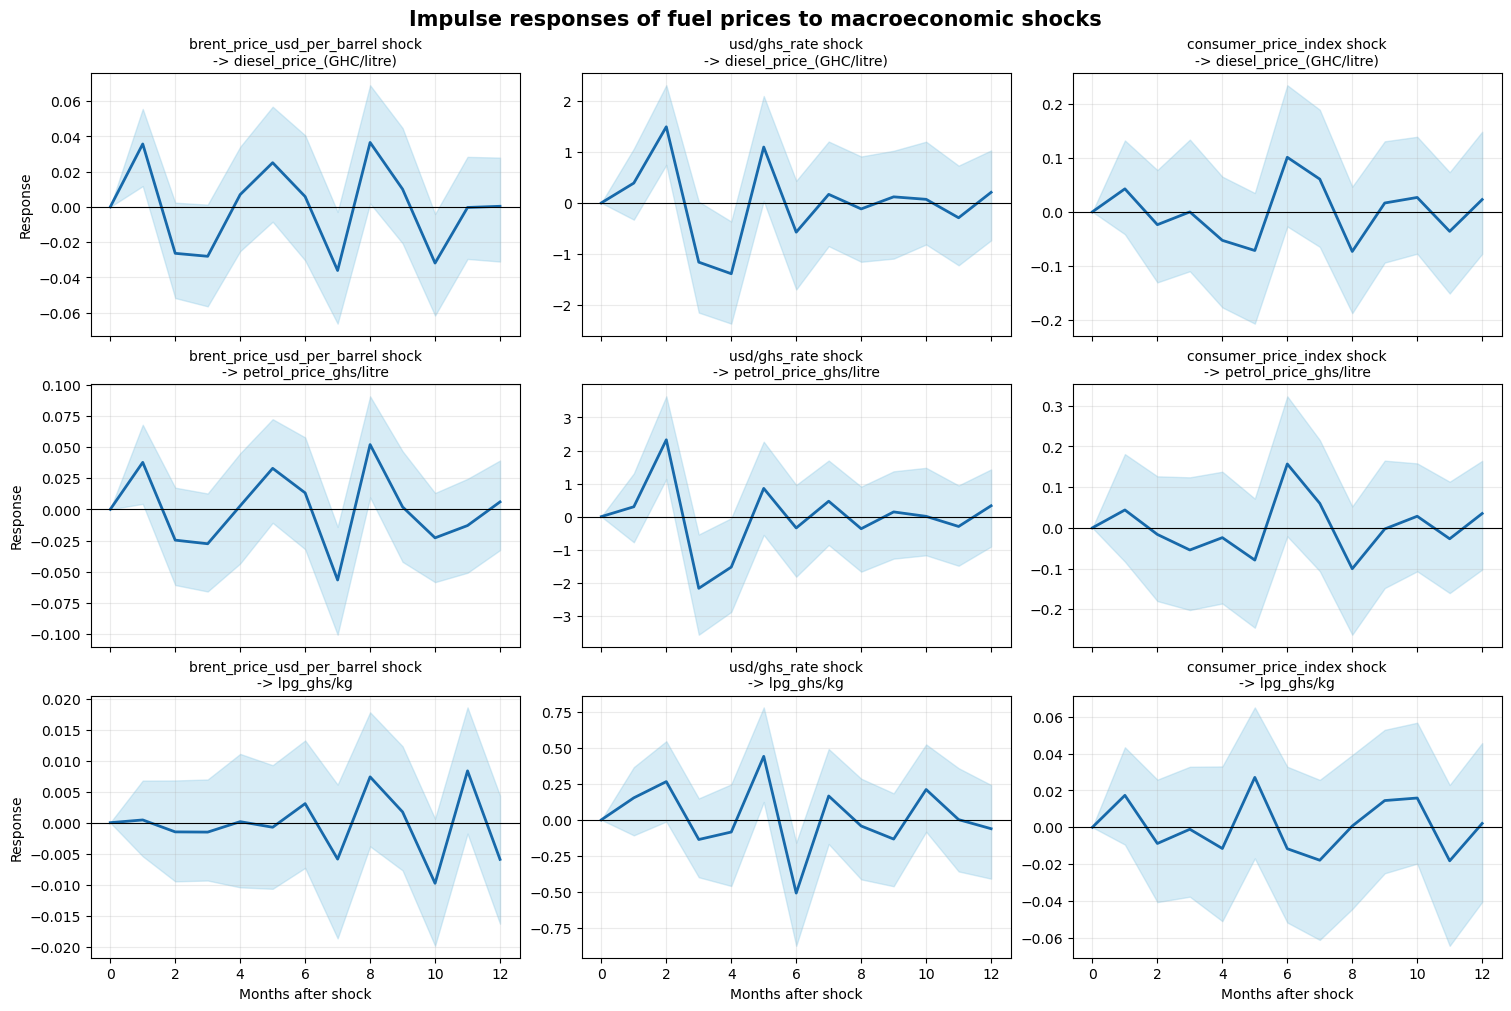

In [6]:
# Focused impulse-response view: macroeconomic shocks -> fuel-price responses.
irf = var_fit.irf(12)
irf_mean = irf.irfs
irf_lower, irf_upper = irf.errband_mc(orth=False, repl=500, signif=0.05)
response_indices = [var_cols.index(column) for column in fuel_cols]
impulse_indices = [var_cols.index(column) for column in external_cols]

fig, axes = plt.subplots(
    nrows=len(fuel_cols),
    ncols=len(external_cols),
    figsize=(15, 10),
    sharex=True,
    constrained_layout=True,
)
for row, response_index in enumerate(response_indices):
    for column, impulse_index in enumerate(impulse_indices):
        axis = axes[row, column]
        periods = np.arange(irf_mean.shape[0])
        response = irf_mean[:, response_index, impulse_index]
        axis.plot(periods, response, color="#1769aa", linewidth=2)
        axis.fill_between(
            periods,
            irf_lower[:, response_index, impulse_index],
            irf_upper[:, response_index, impulse_index],
            color="#8ecae6",
            alpha=0.35,
        )
        axis.axhline(0, color="black", linewidth=0.8)
        axis.set_title(
            f"{external_cols[column]} shock\n-> {fuel_cols[row]}",
            fontsize=10,
        )
        axis.grid(alpha=0.25)
        if row == len(fuel_cols) - 1:
            axis.set_xlabel("Months after shock")
        if column == 0:
            axis.set_ylabel("Response")

fig.suptitle(
    "Impulse responses of fuel prices to macroeconomic shocks",
    fontsize=15,
    fontweight="bold",
)
plt.show()

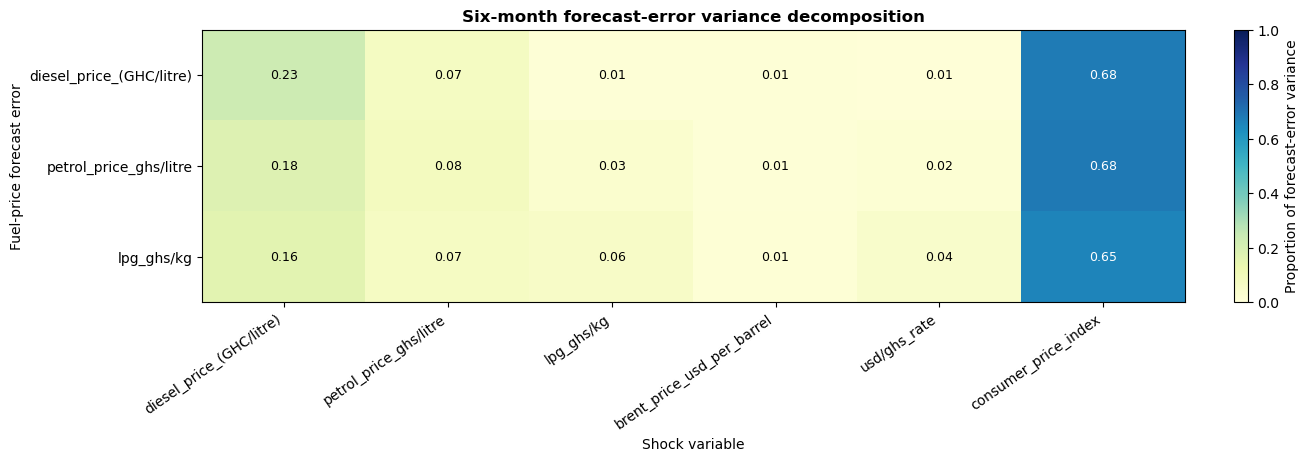

In [7]:
# FEVD heatmap: contribution of each system variable at the six-month horizon.
fevd = var_fit.fevd(6)
fevd_values = fevd.decomp[5, response_indices, :]
fig, axis = plt.subplots(figsize=(13, 4.5), constrained_layout=True)
image = axis.imshow(fevd_values, cmap="YlGnBu", vmin=0, vmax=1, aspect="auto")
axis.set_xticks(range(len(var_cols)), var_cols, rotation=35, ha="right")
axis.set_yticks(range(len(fuel_cols)), fuel_cols)
axis.set_xlabel("Shock variable")
axis.set_ylabel("Fuel-price forecast error")
axis.set_title("Six-month forecast-error variance decomposition", fontweight="bold")
for row in range(fevd_values.shape[0]):
    for column in range(fevd_values.shape[1]):
        axis.text(
            column,
            row,
            f"{fevd_values[row, column]:.2f}",
            ha="center",
            va="center",
            color="white" if fevd_values[row, column] > 0.5 else "black",
            fontsize=9,
        )
fig.colorbar(image, ax=axis, label="Proportion of forecast-error variance")
plt.show()


Six-month VAR forecast metrics:
  model                    series       MAE      RMSE       MAPE
0   VAR  diesel_price_(GHC/litre)  2.045621  2.168345  14.769471
1   VAR    petrol_price_ghs/litre  2.221867  2.337816  14.391091
2   VAR                lpg_ghs/kg  0.219835  0.275709   1.628407


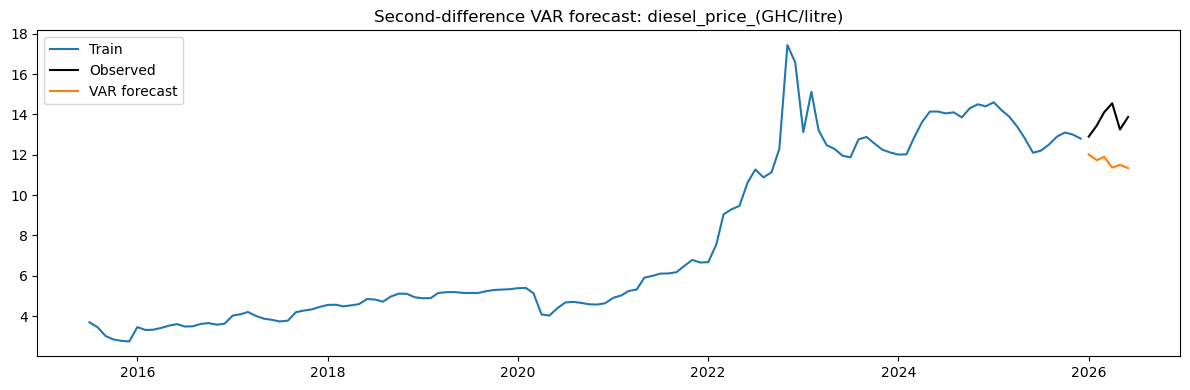

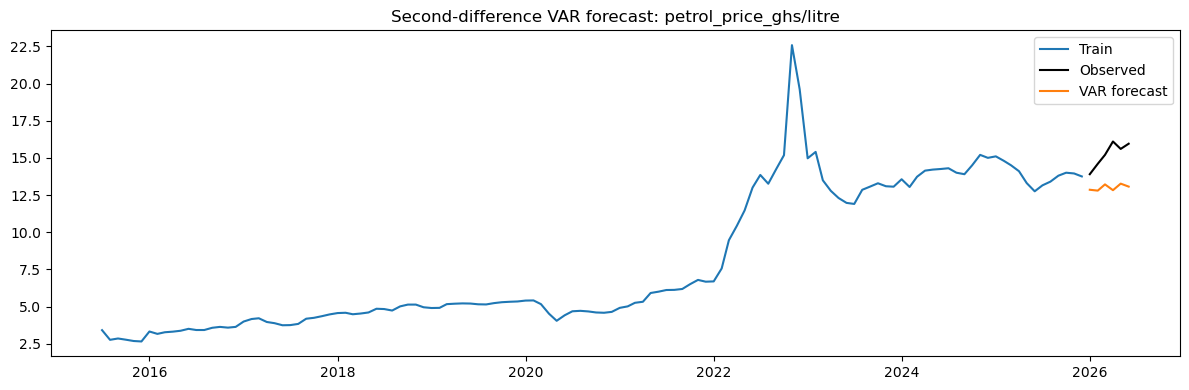

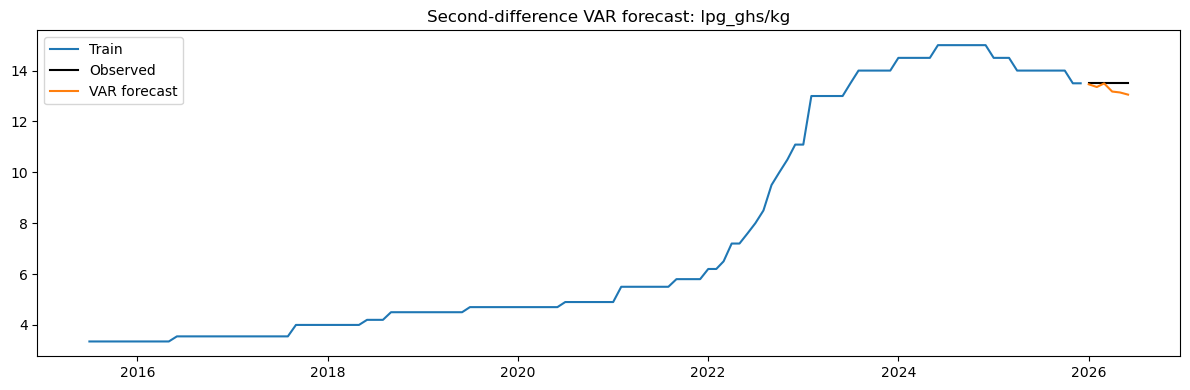

In [8]:
# Forecast second differences, integrate twice, and return to price levels.
lagged_values = train_diff2.values[-selected_lag:]
diff2_forecast = var_fit.forecast(y=lagged_values, steps=horizon)
diff2_forecast = pd.DataFrame(
    diff2_forecast,
    index=test.index,
    columns=var_cols,
)
last_level = train[var_cols].iloc[-1]
last_first_difference = train[var_cols].diff().dropna().iloc[-1]
first_difference_forecast = pd.DataFrame(
    last_first_difference.to_numpy() + diff2_forecast.cumsum().to_numpy(),
    index=test.index,
    columns=var_cols,
)
level_forecast = pd.DataFrame(
    last_level.to_numpy() + first_difference_forecast.cumsum().to_numpy(),
    index=test.index,
    columns=var_cols,
)

var_metrics = []
for column in fuel_cols:
    errors = test[column] - level_forecast[column]
    var_metrics.append(
        {
            "model": "VAR",
            "series": column,
            "MAE": mean_absolute_error(test[column], level_forecast[column]),
            "RMSE": np.sqrt(mean_squared_error(test[column], level_forecast[column])),
            "MAPE": np.mean(np.abs(errors / test[column])) * 100,
        }
    )

var_metrics = pd.DataFrame(var_metrics)
print("\nSix-month VAR forecast metrics:")
print(var_metrics)

for column in fuel_cols:
    plt.figure(figsize=(12, 4))
    plt.plot(train.index, train[column], label="Train")
    plt.plot(test.index, test[column], label="Observed", color="black")
    plt.plot(level_forecast.index, level_forecast[column], label="VAR forecast")
    plt.title(f"Second-difference VAR forecast: {column}")
    plt.legend()
    plt.tight_layout()
    plt.show()

## Robustness check: lag-2 (BIC-preferred) vs lag-6 (AIC-preferred)

Lag-order selection above shows AIC and BIC disagree: AIC favors lag 6, BIC favors lag 2.
Given the small effective sample (~118-122 observations for 6 variables), lag 6 raises a
legitimate overparameterization concern (37 parameters per equation vs. 13 for lag 2).
This check compares the two directly on residual diagnostics and six-month holdout accuracy
before committing to lag 6 as the final specification.

In [9]:
# Compare lag 2 (BIC-preferred, parsimonious) against lag 6 (AIC-preferred, selected above)
comparison_rows = []
for lag in [2, 6]:
    fit_cmp = model.fit(lag)
    wt_cmp = fit_cmp.test_whiteness(nlags=10)
    nt_cmp = fit_cmp.test_normality()

    lagged_values_cmp = train_diff2.values[-lag:]
    diff2_fc = pd.DataFrame(fit_cmp.forecast(y=lagged_values_cmp, steps=horizon),
                             index=test.index, columns=var_cols)
    last_level_cmp = train[var_cols].iloc[-1]
    last_fd_cmp = train[var_cols].diff().dropna().iloc[-1]
    fd_fc = pd.DataFrame(last_fd_cmp.to_numpy() + diff2_fc.cumsum().to_numpy(),
                          index=test.index, columns=var_cols)
    level_fc = pd.DataFrame(last_level_cmp.to_numpy() + fd_fc.cumsum().to_numpy(),
                             index=test.index, columns=var_cols)

    n_obs_cmp = len(train_diff2) - lag
    n_params_cmp = 1 + len(var_cols) * lag

    for col in fuel_cols:
        err = test[col] - level_fc[col]
        comparison_rows.append({
            "lag": lag,
            "series": col,
            "stable": fit_cmp.is_stable(),
            "obs_per_param": round(n_obs_cmp / n_params_cmp, 2),
            "whiteness_stat": round(wt_cmp.test_statistic, 2),
            "whiteness_p": round(wt_cmp.pvalue, 4),
            "normality_stat": round(nt_cmp.test_statistic, 2),
            "normality_p": round(nt_cmp.pvalue, 4),
            "MAE": round(mean_absolute_error(test[col], level_fc[col]), 4),
            "RMSE": round(np.sqrt(mean_squared_error(test[col], level_fc[col])), 4),
        })

comparison_df = pd.DataFrame(comparison_rows)
print("Lag-2 vs Lag-6 robustness comparison:")
print(comparison_df.to_string(index=False))
print()
print("Interpretation: lag 2 has a healthier observations-to-parameter ratio but does NOT")
print("improve residual normality (it worsens substantially) and gives weaker six-month")
print("forecast accuracy for petrol and LPG. This suggests the residual non-normality is")
print("driven primarily by the 2021-2022 structural shock (see Zivot-Andrews results,")
print("Notebook 02) rather than lag-6 overparameterization. Lag 6 is retained.")


Lag-2 vs Lag-6 robustness comparison:
 lag                   series  stable  obs_per_param  whiteness_stat  whiteness_p  normality_stat  normality_p    MAE   RMSE
   2 diesel_price_(GHC/litre)    True           9.38          473.06          0.0          861.07          0.0 1.9805 2.1160
   2   petrol_price_ghs/litre    True           9.38          473.06          0.0          861.07          0.0 2.8416 3.0609
   2               lpg_ghs/kg    True           9.38          473.06          0.0          861.07          0.0 0.5031 0.5671
   6 diesel_price_(GHC/litre)    True           3.19          277.51          0.0          251.34          0.0 2.0456 2.1683
   6   petrol_price_ghs/litre    True           3.19          277.51          0.0          251.34          0.0 2.2219 2.3378
   6               lpg_ghs/kg    True           3.19          277.51          0.0          251.34          0.0 0.2198 0.2757

Interpretation: lag 2 has a healthier observations-to-parameter ratio but does NOT
imp